In [2]:
import pandas as pd


In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")



In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [5]:
train["demand"].describe()


count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

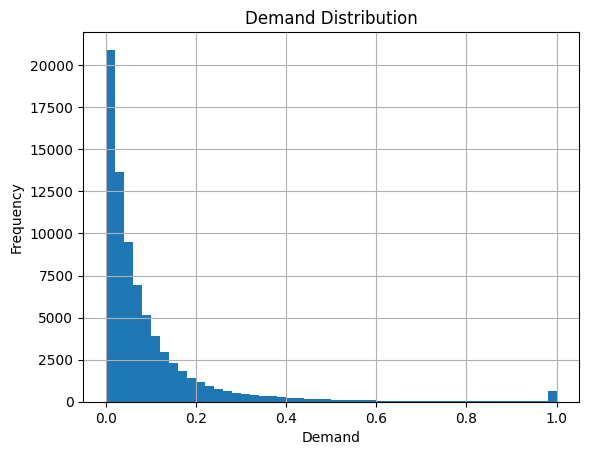

In [6]:
import matplotlib.pyplot as plt

train["demand"].hist(bins=50)

plt.title("Demand Distribution")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.show()

In [7]:
for col in ["geohash", "RoadType", "LargeVehicles", "Landmarks", "Weather"]:
    print("\n", col)
    print(train[col].value_counts().head(10))


 geohash
geohash
qp03xk    105
qp092r    105
qp03wz    105
qp03xp    105
qp097y    105
qp03r0    105
qp03r2    105
qp03xx    105
qp096y    105
qp096w    105
Name: count, dtype: int64

 RoadType
RoadType
Residential    69230
Street          3909
Highway         3560
Name: count, dtype: int64

 LargeVehicles
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

 Landmarks
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

 Weather
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64


In [8]:
print("Unique geohashes:", train["geohash"].nunique())

Unique geohashes: 1249


In [9]:
print(train["day"].value_counts().sort_index())

day
48    69427
49     7872
Name: count, dtype: int64


In [10]:
print(train.groupby("day")["demand"].describe())

       count      mean       std           min       25%       50%       75%  \
day                                                                            
48   69427.0  0.092659  0.141837  6.245650e-07  0.017904  0.046806  0.106439   
49    7872.0  0.105262  0.144792  7.981559e-07  0.021368  0.055901  0.127472   

     max  
day       
48   1.0  
49   1.0  


In [11]:
train.groupby("timestamp")["demand"].mean().sort_values(ascending=False).head(10)

timestamp
13:30    0.119193
11:15    0.119174
14:0     0.117821
12:0     0.117790
11:30    0.117561
11:45    0.117129
13:45    0.117046
13:15    0.116641
11:0     0.115395
12:15    0.114676
Name: demand, dtype: float64

In [12]:
train.groupby("timestamp")["demand"].mean().sort_values().head(10)

timestamp
19:30    0.040214
20:45    0.041171
19:45    0.041177
19:15    0.043151
20:30    0.043785
19:0     0.044141
20:15    0.044885
20:0     0.045515
18:45    0.045730
18:30    0.046713
Name: demand, dtype: float64

In [13]:
train.groupby("Weather")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
Weather,,,,,,,,
Foggy,20243.0,0.093372,0.141110,6.138162e-06,0.018215,0.047571,0.108625,1.0
Rainy,20824.0,0.094471,0.141608,7.981559e-07,0.018083,0.048467,0.110044,1.0
Snowy,7718.0,0.092581,0.138300,3.994529e-06,0.018214,0.047775,0.108075,1.0
Sunny,27717.0,0.094247,0.144367,6.245650e-07,0.018258,0.047230,0.107245,1.0


In [14]:
train.groupby("RoadType")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
RoadType,,,,,,,,
Highway,3560.0,0.610756,0.229419,3.500089e-01,0.413629,0.526432,0.790095,1.000000
Residential,69230.0,0.057209,0.052057,6.245650e-07,0.016203,0.040517,0.084468,0.219997
Street,3909.0,0.273164,0.036693,2.200159e-01,0.240702,0.268124,0.301890,0.349908


In [15]:
train.groupby("NumberofLanes")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
NumberofLanes,,,,,,,,
1,27411.0,0.088104,0.090681,3.896741e-06,0.019475,0.052204,0.126136,0.349908
2,24127.0,0.077488,0.124543,1.408894e-06,0.016800,0.043005,0.092359,1.000000
3,23919.0,0.077859,0.125011,6.245650e-07,0.017063,0.042845,0.092126,1.000000
4,926.0,0.602882,0.225795,3.502258e-01,0.412532,0.513090,0.780396,1.000000
5,916.0,0.607556,0.226946,3.500089e-01,0.413233,0.521678,0.779799,1.000000


In [16]:
train.groupby("LargeVehicles")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
LargeVehicles,,,,,,,,
Allowed,26626.0,0.131923,0.212567,6.245650e-07,0.019261,0.051223,0.122294,1.000000
Not Allowed,50673.0,0.073986,0.077097,1.408894e-06,0.017699,0.046023,0.102839,0.349908


In [17]:
train.groupby("Landmarks")["demand"].describe()

,count,mean,std,min,25%,50%,75%,max
Landmarks,,,,,,,,
No,25257.0,0.096295,0.162751,3.896741e-06,0.017723,0.045579,0.100368,1.0
Yes,52042.0,0.092801,0.131041,6.245650e-07,0.018476,0.048974,0.112958,1.0


In [18]:
train["Temperature"].describe()

count    74804.000000
mean        16.405354
std          7.359835
min        -14.935097
25%         11.430473
50%         16.382587
75%         21.298833
max         48.251433
Name: Temperature, dtype: float64

In [19]:
train[["Temperature", "demand"]].corr()

,Temperature,demand
Temperature,1.000000,0.003144
demand,0.003144,1.000000


In [20]:
pd.crosstab(
    train["RoadType"],
    train["NumberofLanes"]
)

NumberofLanes,1,2,3,4,5
RoadType,,,,,
Highway,0,855,881,915,909
Residential,23269,23091,22870,0,0
Street,3909,0,0,0,0


In [21]:
for col in ["geohash", "RoadType", "LargeVehicles", "Landmarks", "Weather"]:
    print(col, ":", train[col].nunique())

geohash : 1249
RoadType : 3
LargeVehicles : 2
Landmarks : 2
Weather : 4


In [22]:
from sklearn.model_selection import train_test_split

X = train.drop("demand", axis=1)
y = train["demand"]

print(X.shape)
print(y.shape)

(77299, 10)
(77299,)


In [23]:
X = train.drop("demand", axis=1).copy()

X["hour"] = X["timestamp"].str.split(":").str[0].astype(int)
X["minute"] = X["timestamp"].str.split(":").str[1].astype(int)

print(X[["timestamp", "hour", "minute"]].head())

  timestamp  hour  minute
0       0:0     0       0
1       0:0     0       0
2       0:0     0       0
3       0:0     0       0
4       0:0     0       0


In [24]:
train_temp = train.copy()

train_temp["hour"] = (
    train_temp["timestamp"]
    .str.split(":")
    .str[0]
    .astype(int)
)

train_temp.groupby("hour")["demand"].mean().sort_values(ascending=False)

hour
11    0.117301
13    0.116308
12    0.114770
10    0.111602
9     0.109231
14    0.107166
7     0.106198
8     0.106149
5     0.104368
6     0.103913
4     0.101678
23    0.092517
3     0.091329
1     0.089793
2     0.087368
0     0.083369
15    0.083161
22    0.074544
16    0.070065
17    0.058905
21    0.056955
18    0.048787
20    0.043778
19    0.042114
Name: demand, dtype: float64

In [25]:
X = train.drop("demand", axis=1).copy()

X["hour"] = X["timestamp"].str.split(":").str[0].astype(int)
X["minute"] = X["timestamp"].str.split(":").str[1].astype(int)

X["midday_peak"] = (
    (X["hour"] >= 9) &
    (X["hour"] <= 14)
).astype(int)

X["evening_low"] = (
    (X["hour"] >= 18) &
    (X["hour"] <= 21)
).astype(int)

print(
    X[[
        "hour",
        "minute",
        "midday_peak",
        "evening_low"
    ]].head()
)

   hour  minute  midday_peak  evening_low
0     0       0            0            0
1     0       0            0            0
2     0       0            0            0
3     0       0            0            0
4     0       0            0            0


In [26]:
X = X.drop("timestamp", axis=1)

print(X.columns)

Index(['Index', 'geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles',
       'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'midday_peak',
       'evening_low'],
      dtype='object')


In [27]:
print(X.dtypes)

Index              int64
geohash           object
day                int64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
hour               int32
minute             int32
midday_peak        int32
evening_low        int32
dtype: object


In [28]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather"
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

print(X.dtypes)

Index              int64
geohash            int32
day                int64
RoadType           int32
NumberofLanes      int64
LargeVehicles      int32
Landmarks          int32
Temperature      float64
Weather            int32
hour               int32
minute             int32
midday_peak        int32
evening_low        int32
dtype: object


In [29]:
print(X.dtypes)

Index              int64
geohash            int32
day                int64
RoadType           int32
NumberofLanes      int64
LargeVehicles      int32
Landmarks          int32
Temperature      float64
Weather            int32
hour               int32
minute             int32
midday_peak        int32
evening_low        int32
dtype: object


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)

(61839, 13)
(15460, 13)


In [31]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Training completed!")

Training completed!


In [32]:
from sklearn.metrics import mean_squared_error
import numpy as np

preds = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, preds))

print("RMSE:", rmse)

RMSE: 0.03427281728576194


In [33]:
import pandas as pd

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance)

          feature  importance
3        RoadType    0.747695
1         geohash    0.161547
0           Index    0.034909
9            hour    0.019426
7     Temperature    0.017767
4   NumberofLanes    0.006019
10         minute    0.003906
11    midday_peak    0.002798
8         Weather    0.002723
6       Landmarks    0.001379
5   LargeVehicles    0.000847
2             day    0.000622
12    evening_low    0.000361


In [34]:
X_no_index = X.drop("Index", axis=1)

from sklearn.model_selection import train_test_split

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_no_index,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model2.fit(X_train2, y_train2)

from sklearn.metrics import mean_squared_error
import numpy as np

preds2 = model2.predict(X_val2)

rmse2 = np.sqrt(mean_squared_error(y_val2, preds2))

print("RMSE without Index:", rmse2)

RMSE without Index: 0.03470350106544409


In [35]:
print(test.columns)

Index(['Index', 'geohash', 'day', 'timestamp', 'RoadType', 'NumberofLanes',
       'LargeVehicles', 'Landmarks', 'Temperature', 'Weather'],
      dtype='object')


In [36]:
X_test = test.copy()

# Time features
X_test["hour"] = X_test["timestamp"].str.split(":").str[0].astype(int)
X_test["minute"] = X_test["timestamp"].str.split(":").str[1].astype(int)

X_test["midday_peak"] = (
    (X_test["hour"] >= 9) &
    (X_test["hour"] <= 14)
).astype(int)

X_test["evening_low"] = (
    (X_test["hour"] >= 18) &
    (X_test["hour"] <= 21)
).astype(int)

# Remove timestamp
X_test.drop("timestamp", axis=1, inplace=True)

print(X_test.shape)

(41778, 13)


In [38]:
train_geohashes = set(train["geohash"].unique())
test_geohashes = set(test["geohash"].unique())

unseen = test_geohashes - train_geohashes

print("Unseen geohashes:", len(unseen))
print(list(unseen)[:20])

Unseen geohashes: 10
['qp09vh', 'qp09j5', 'qp09tv', 'qp08ch', 'qp08g4', 'qp0dn1', 'qp091d', 'qp09y0', 'qp091n', 'qp0965']


In [39]:
print(len(encoders["geohash"].classes_))

1249


In [40]:
geo_map = {v: i for i, v in enumerate(encoders["geohash"].classes_)}

X_test["geohash"] = X_test["geohash"].map(geo_map)

X_test["geohash"] = X_test["geohash"].fillna(len(geo_map)).astype(int)

print(X_test["geohash"].isnull().sum())

0


In [41]:
for col in ["RoadType", "LargeVehicles", "Landmarks", "Weather"]:
    X_test[col] = encoders[col].transform(X_test[col])

pred_test = model.predict(X_test)

print(pred_test[:10])

[0.14326144 0.03280055 0.03987192 0.0258796  0.04159843 0.05445994
 0.02369724 0.06492989 0.02002726 0.07947288]


In [42]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": pred_test
})

print(submission.shape)
print(submission.head())

(41778, 2)
   Index    demand
0      0  0.143261
1      1  0.032801
2      2  0.039872
3      3  0.025880
4      4  0.041598


In [43]:
submission.to_csv("submission.csv", index=False)

In [44]:
!pip install catboost


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [46]:
print(train.dtypes)

Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object


In [47]:
train_cb = train.copy()

train_cb["hour"] = train_cb["timestamp"].str.split(":").str[0].astype(int)
train_cb["minute"] = train_cb["timestamp"].str.split(":").str[1].astype(int)

train_cb["midday_peak"] = (
    (train_cb["hour"] >= 9) &
    (train_cb["hour"] <= 14)
).astype(int)

train_cb["evening_low"] = (
    (train_cb["hour"] >= 18) &
    (train_cb["hour"] <= 21)
).astype(int)

train_cb.drop("timestamp", axis=1, inplace=True)

print(train_cb.shape)

(77299, 14)


In [48]:
X_cb = train_cb.drop("demand", axis=1)
y_cb = train_cb["demand"]

print(X_cb.shape)
print(y_cb.shape)

(77299, 13)
(77299,)


In [49]:
print(X_cb.columns.tolist())

['Index', 'geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'midday_peak', 'evening_low']


In [50]:
from sklearn.model_selection import train_test_split

X_train_cb, X_val_cb, y_train_cb, y_val_cb = train_test_split(
    X_cb,
    y_cb,
    test_size=0.2,
    random_state=42
)

print(X_train_cb.shape)
print(X_val_cb.shape)

(61839, 13)
(15460, 13)


In [51]:
from catboost import CatBoostRegressor

cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather"
]

cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

cb_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_features,
    eval_set=(X_val_cb, y_val_cb),
    use_best_model=True
)

CatBoostError: Invalid type for cat_feature[non-default value idx=841,feature_idx=3]=nan : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [52]:
X_cb.isnull().sum()


Index               0
geohash             0
day                 0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
hour                0
minute              0
midday_peak         0
evening_low         0
dtype: int64

In [53]:
# Categorical columns
X_cb["RoadType"] = X_cb["RoadType"].fillna("Missing")
X_cb["Weather"] = X_cb["Weather"].fillna("Missing")

# Numerical column
X_cb["Temperature"] = X_cb["Temperature"].fillna(
    X_cb["Temperature"].median()
)

print(X_cb.isnull().sum())

Index            0
geohash          0
day              0
RoadType         0
NumberofLanes    0
LargeVehicles    0
Landmarks        0
Temperature      0
Weather          0
hour             0
minute           0
midday_peak      0
evening_low      0
dtype: int64


In [54]:
from sklearn.model_selection import train_test_split

X_train_cb, X_val_cb, y_train_cb, y_val_cb = train_test_split(
    X_cb,
    y_cb,
    test_size=0.2,
    random_state=42
)

In [55]:
from catboost import CatBoostRegressor

cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather"
]

cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

cb_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_features,
    eval_set=(X_val_cb, y_val_cb),
    use_best_model=True
)

0:	learn: 0.1369145	test: 0.1368857	best: 0.1368857 (0)	total: 241ms	remaining: 4m 1s
100:	learn: 0.0447017	test: 0.0442457	best: 0.0442457 (100)	total: 7.9s	remaining: 1m 10s
200:	learn: 0.0406706	test: 0.0406456	best: 0.0406456 (200)	total: 16.2s	remaining: 1m 4s
300:	learn: 0.0380820	test: 0.0386388	best: 0.0386388 (300)	total: 24.6s	remaining: 57.1s
400:	learn: 0.0367565	test: 0.0376319	best: 0.0376319 (400)	total: 32.9s	remaining: 49.1s
500:	learn: 0.0355774	test: 0.0367789	best: 0.0367789 (500)	total: 41.6s	remaining: 41.5s
600:	learn: 0.0345536	test: 0.0361360	best: 0.0361334 (598)	total: 50.4s	remaining: 33.5s
700:	learn: 0.0335805	test: 0.0355756	best: 0.0355756 (700)	total: 59.2s	remaining: 25.3s
800:	learn: 0.0327944	test: 0.0351318	best: 0.0351318 (800)	total: 1m 8s	remaining: 16.9s
900:	learn: 0.0319550	test: 0.0346767	best: 0.0346720 (898)	total: 1m 17s	remaining: 8.52s
999:	learn: 0.0312415	test: 0.0342976	best: 0.0342976 (999)	total: 1m 27s	remaining: 0us

bestTest = 0.

In [56]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred_cb = cb_model.predict(X_val_cb)

rmse_cb = np.sqrt(mean_squared_error(y_val_cb, pred_cb))

print(rmse_cb)

0.03429760408258834
